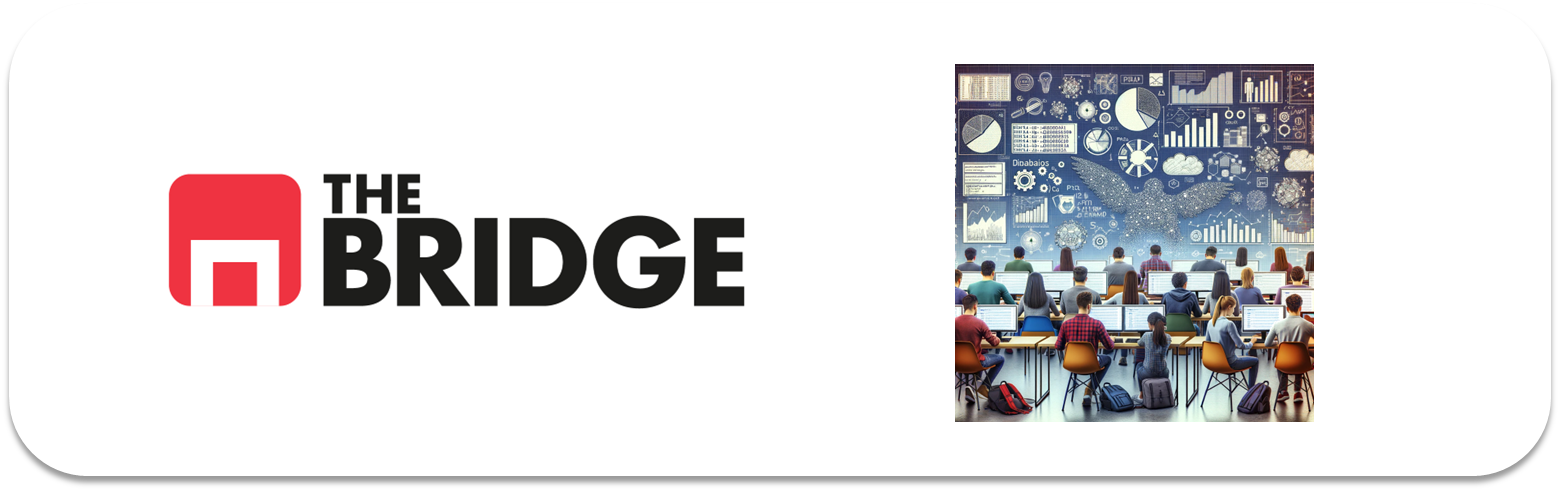

## PRACTICA OBLIGATORIA: **Regresion Lineal y Regularización**

* La práctica obligatoria de esta unidad consiste en hacer un modelado completo de un problema que ya conoces, la predicción de casas, pero con otro dataset. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Modelo de Regresión Lineal

El objetivo del modelo que tienes que construir es predecir la mediana del precio de las casas en una zona del área metropolitana de Boston dadas las características de las mismas. Sí, es parecido pero no igual a lo que hemos venido haciendo.

Aquí tienes una descripción de las variables del dataset, del que tendrás que decidir el target:  

***CRIM:*** Tasa de criminalidad per cápita por ciudad  
***ZN:*** Proporción de terreno residencial destinado a lotes de más de 25,000 pies cuadrados  
***INDUS:*** Proporción de acres de negocios no minoristas por ciudad  
***CHAS:*** Variable ficticia del río Charles (= 1 si el sector limita con el río; 0 en caso contrario)  
***NOX:*** Concentración de óxidos de nitrógeno (partes por 10 millones)  
***RM:*** Número promedio de habitaciones por vivienda  
***AGE:*** Proporción de unidades ocupadas por el propietario construidas antes de 1940  
***DIS:*** Distancias ponderadas a cinco centros de empleo de Boston  
***RAD:*** Índice de accesibilidad a autopistas radiales  
***TAX:*** Tasa de impuesto sobre la propiedad de valor total por $10,000  
***PTRATIO:*** Relación alumno-maestro por ciudad  
***LSTAT:*** % de población de estatus socioeconómico bajo  
***MEDV:*** Valor medio de las viviendas ocupadas por sus propietarios en miles de dólares  

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
import itertools
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn import linear_model, model_selection
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge



### Indicaciones

A continuación tienes las indicaciones para hacer el modelado. No necesariamente tienes que seguirlos al pie de la letra, porque a partir de ahora ya las práctica obligatorias dejarán de ser mayormente guiadas por ejercicios y serán más de libre desarrollo, aunque con objetivos específicos, claros y determinados. 

En concreto se pide hacer un modelo de regresión lineal, evaluarlo contra un dataset de test reservado del original mostrando MAE,RMSE,MSE y $R2$, comparar las predicciones con los valores reales y realizar al menos un tipo de regularización de las conocidas, testando por lo menos 3 valores diferentes de hiperparámetros.

Los pasos para guiar el trabajo:
1. Carga el dataset. Está limpio y no necesitarás completar nulos, ni repasar los valores de las columnas.
2. Escoge y analiza la variable target de forma gráfica para ver la idoneidad de hacer un modelo de regresión.
3. Haz el split en train y test que creas conveniente y de la forma que creas conveniente.
4. Construye las parejas X,y de train y test
5. Haz un mini-EDA, selecciona las features que quieres quedarte y por qué.
6. Trata las variables para que funcionen lo mejor posible en el modelo.
7. Construye un modelo de regresión lineal.
8. Analiza si lo crees conveniente los pesos y la importancia de las features.
8. Evalúa tu modelo. Haz un pequeño assesmente de su generabilidad. Compara gráficamente las predicciones con los valores reales.
9. Regulariza al menos con un modelo alternativo y juega con 3 posibles valores de los hiperparámetros del modelo de regularización.
10. Expresa tus conclusiones, en concreto ¿con qué modelo te quedarías?¿por qué?



1. Carga el dataset. Está limpio y no necesitarás completar nulos, ni repasar los valores de las columnas.

In [10]:
df = pd.read_csv("./data/hard_to_find/obligatoria_hard.csv", delimiter="|")
df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1.0,273.0,21.0,9.67,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1.0,273.0,21.0,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1.0,273.0,21.0,5.64,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1.0,273.0,21.0,6.48,22.0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  LSTAT    506 non-null    float64
 12  MEDV     506 non-null    float64
dtypes: float64(13)
memory usage: 51.5 KB


2. Escoge y analiza la variable target de forma gráfica para ver la idoneidad de hacer un modelo de regresión.

<Axes: xlabel='MEDV', ylabel='Count'>

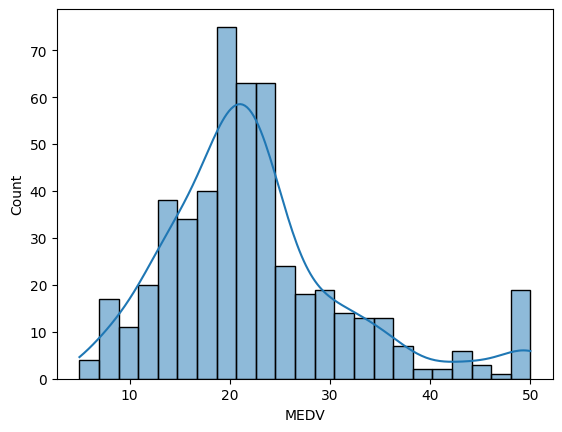

In [12]:
target = ["MEDV"]
sns.histplot(df["MEDV"], kde= True)

3. Haz el split en train y test que creas conveniente y de la forma que creas conveniente.

In [13]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

print(f"Total muestras:  {len(df)}")
print(f"Train:           {train_df.shape}")
print(f"Test:            {test_df.shape}")

Total muestras:  506
Train:           (404, 13)
Test:            (102, 13)


4. Construye las parejas X,y de train y test

In [14]:
X_train = train_df.drop(columns=["MEDV"])
y_train = train_df[target]

X_test = test_df.drop(columns=["MEDV"])
y_test = test_df[target]

5. Haz un mini-EDA, selecciona las features que quieres quedarte y por qué.

In [15]:
train_df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
count,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000
mean,3.609125,11.569307,10.985050,0.071782,0.556484,6.315891,68.556436,3.808195,9.356436,404.032178,18.318317,12.457351,22.796535
std,8.875058,23.152481,6.894618,0.258447,0.117704,0.709452,27.994922,2.131226,8.589721,166.172655,2.228701,7.110381,9.332147
min,0.009060,0.000000,0.740000,0.000000,0.385000,3.863000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,0.081437,0.000000,5.130000,0.000000,0.452000,5.890500,45.550000,2.087875,4.000000,279.000000,16.800000,6.772500,16.950000
50%,0.261390,0.000000,8.560000,0.000000,0.538000,6.210000,77.700000,3.175750,5.000000,330.000000,18.700000,10.925000,21.600000
75%,3.202962,20.000000,18.100000,0.000000,0.631000,6.636750,93.650000,5.400800,12.000000,666.000000,20.200000,16.372500,26.400000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


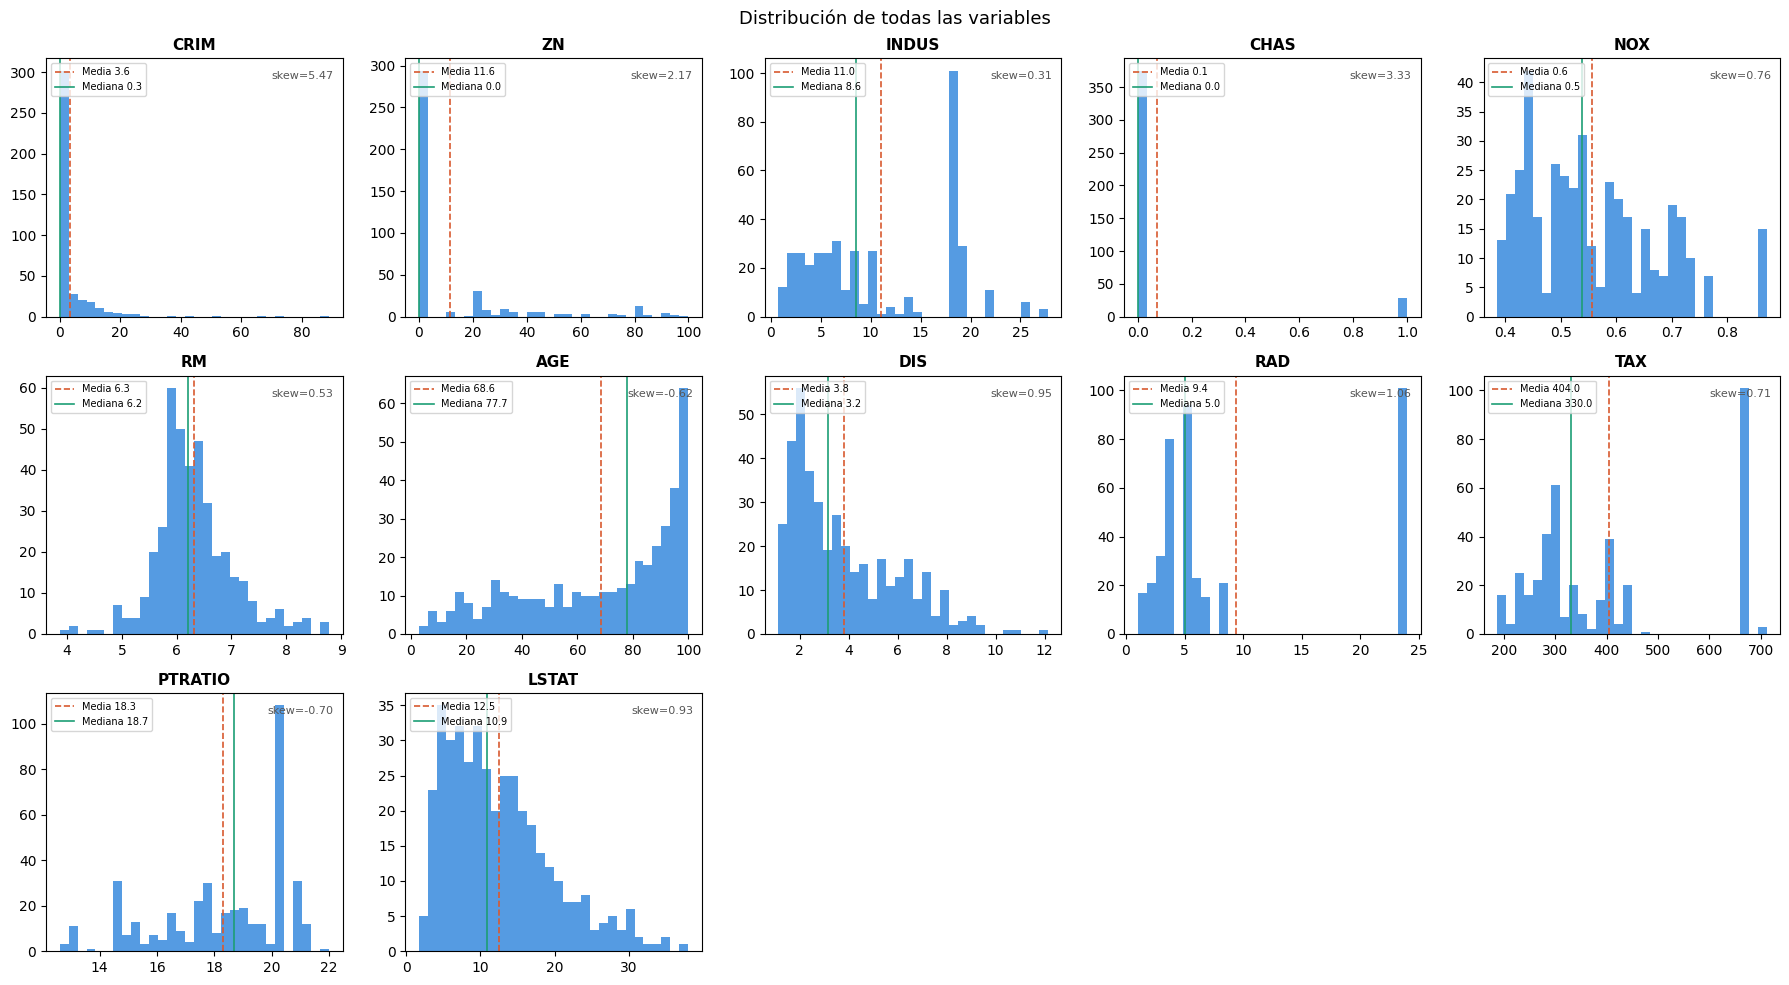

In [16]:
# Histogramas de todas las features
all_cols = [c for c in train_df.columns if c != "MEDV"]

fig, axes = plt.subplots(3, 5, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(all_cols):
    ax = axes[i]
    skv = train_df[col].skew()
    mean = train_df[col].mean()
    median = train_df[col].median()

    ax.hist(train_df[col], bins=30, color="#378ADD", edgecolor="none", alpha=0.85)

    ax.axvline(mean,   color="#D85A30", linewidth=1.2, linestyle="--", label=f"Media {mean:.1f}")
    ax.axvline(median, color="#1D9E75", linewidth=1.2, linestyle="-",  label=f"Mediana {median:.1f}")

    ax.set_title(col, fontsize=11, fontweight="bold")
    ax.text(0.97, 0.95, f"skew={skv:.2f}", transform=ax.transAxes,
            ha="right", va="top", fontsize=8, color="#555")
    ax.legend(fontsize=7, loc="upper left")

for j in range(len(all_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Distribución de todas las variables", fontsize=13)
plt.tight_layout()
plt.show()

In [17]:
print("\n" + "=" * 60)
print("ASIMETRÍA (|skew| > 1 → distribución muy asimétrica)")
print("=" * 60)
skew = train_df.skew().sort_values(ascending=False)
print(skew.round(3).to_string())
high_skew = skew[abs(skew) > 1].index.tolist()
print(f"\nFeatures con |skew| > 1: {high_skew}")


ASIMETRÍA (|skew| > 1 → distribución muy asimétrica)
CRIM       5.465
CHAS       3.330
ZN         2.168
RAD        1.060
MEDV       1.049
DIS        0.952
LSTAT      0.934
NOX        0.757
TAX        0.712
RM         0.530
INDUS      0.314
AGE       -0.619
PTRATIO   -0.704

Features con |skew| > 1: ['CRIM', 'CHAS', 'ZN', 'RAD', 'MEDV']


In [18]:
print("\n" + "=" * 60)
print("5. DISTRIBUCIÓN DE VARIABLES ESPECIALES")
print("=" * 60)
print("\nCHAS (binaria):")
print(train_df["CHAS"].value_counts())
chas_pct = train_df["CHAS"].value_counts(normalize=True).mul(100).round(1)
print(f"  → {chas_pct[0]}% son 0, {chas_pct[1]}% son 1  (muy desbalanceada)")

print("\nRAD (valores únicos):")
print(train_df["RAD"].value_counts().sort_index())
print(f"  → {train_df['RAD'].nunique()} valores únicos, distribución bimodal")

print("\nZN (% de ceros):")
zeros_zn = (train_df["ZN"] == 0).sum()
print(f"  → {zeros_zn} de {len(train_df)} observaciones son 0  ({zeros_zn/len(train_df)*100:.1f}%)")



5. DISTRIBUCIÓN DE VARIABLES ESPECIALES

CHAS (binaria):
CHAS
0.0    375
1.0     29
Name: count, dtype: int64
  → 92.8% son 0, 7.2% son 1  (muy desbalanceada)

RAD (valores únicos):
RAD
1.0      17
2.0      21
3.0      32
4.0      80
5.0      94
6.0      23
7.0      15
8.0      21
24.0    101
Name: count, dtype: int64
  → 9 valores únicos, distribución bimodal

ZN (% de ceros):
  → 294 de 404 observaciones son 0  (72.8%)


LSTAT     -0.736422
RM         0.710680
PTRATIO   -0.491210
INDUS     -0.470546
TAX       -0.459795
NOX       -0.415768
RAD       -0.387467
CRIM      -0.380091
AGE       -0.340216
ZN         0.309504
DIS        0.235114
CHAS       0.190642
Name: MEDV, dtype: float64


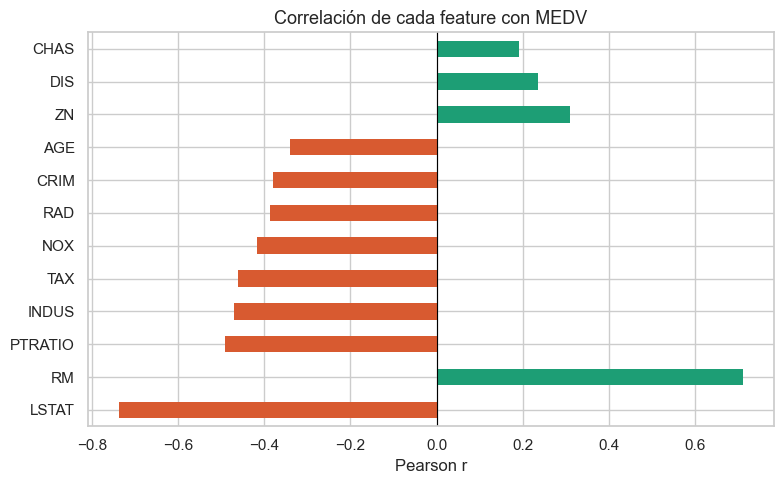

In [19]:
numeric_cols = train_df.select_dtypes(include="number").columns.tolist()
correlaciones = train_df[numeric_cols].corr()["MEDV"].drop("MEDV").sort_values(key=abs, ascending=False)

print(correlaciones)

sns.set_theme(style="whitegrid", palette="muted")

# --- Correlación con target ---
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#D85A30" if v < 0 else "#1D9E75" for v in correlaciones.values]
correlaciones.plot(kind="barh", ax=ax, color=colors, edgecolor="none")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Correlación de cada feature con MEDV", fontsize=13)
ax.set_xlabel("Pearson r")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

In [20]:
print("\n" + "=" * 60)
print("7. PARES CON MULTICOLINEALIDAD ALTA (|r| > 0.7)")
print("=" * 60)
corr_feats = train_df.drop("MEDV", axis=1).corr()
high_pairs = [
    (c1, c2, round(corr_feats.loc[c1, c2], 3))
    for c1, c2 in itertools.combinations(corr_feats.columns, 2)
    if abs(corr_feats.loc[c1, c2]) > 0.7
]
high_pairs.sort(key=lambda x: -abs(x[2]))
for c1, c2, val in high_pairs:
    print(f"  {c1:>8} ↔ {c2:<8}  r = {val:+.3f}")


7. PARES CON MULTICOLINEALIDAD ALTA (|r| > 0.7)
       RAD ↔ TAX       r = +0.913
       NOX ↔ DIS       r = -0.772
     INDUS ↔ NOX       r = +0.771
       AGE ↔ DIS       r = -0.757
       NOX ↔ AGE       r = +0.720
     INDUS ↔ DIS       r = -0.708
     INDUS ↔ TAX       r = +0.702


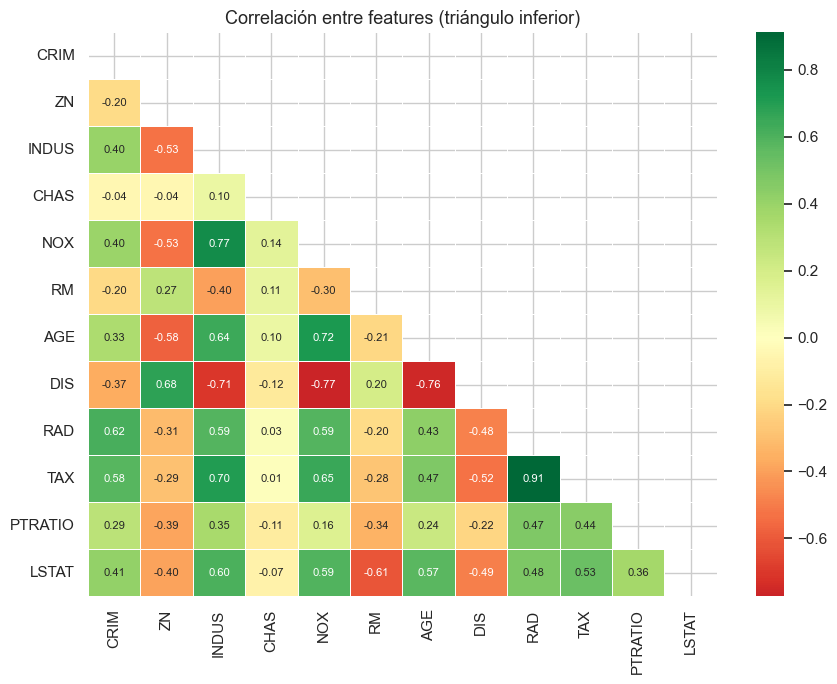

In [21]:
# --- Heatmap de correlación entre features ---
fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_feats, dtype=bool))
sns.heatmap(
    corr_feats, mask=mask, annot=True, fmt=".2f",
    cmap="RdYlGn", center=0, linewidths=0.4,
    annot_kws={"size": 8}, ax=ax
)
ax.set_title("Correlación entre features (triángulo inferior)", fontsize=13)
plt.tight_layout()
plt.show()

In [22]:
SELECCIONADAS = ["LSTAT", "RM", "PTRATIO", "INDUS", "CRIM", "DIS", "ZN", "TAX"]
ELIMINADAS   = ["NOX", "AGE", "RAD", "CHAS"]

print("\n" + "=" * 60)
print("8. SELECCIÓN FINAL DE FEATURES")
print("=" * 60)
print(f"Seleccionadas ({len(SELECCIONADAS)}): {SELECCIONADAS}")
print(f"Descartadas   ({len(ELIMINADAS)}):  {ELIMINADAS}")

reasons = {
    "NOX":  "Alta colinealidad con DIS (0.77). Se conserva DIS por mayor interpretabilidad económica.",
    "AGE":  "Alta colinealidad con DIS (0.75) y NOX (0.73). Redundante con ambas.",
    "RAD":  "Redundante con TAX (r=0.91). TAX tiene mayor correlación con MEDV (−0.47 vs −0.38).",
    "CHAS": "Binaria con 93% de ceros. Correlación mínima con MEDV (+0.18).",
}

print("\nMotivos de descarte:")
for feat, reason in reasons.items():
    print(f"  {feat:>6}: {reason}")


8. SELECCIÓN FINAL DE FEATURES
Seleccionadas (8): ['LSTAT', 'RM', 'PTRATIO', 'INDUS', 'CRIM', 'DIS', 'ZN', 'TAX']
Descartadas   (4):  ['NOX', 'AGE', 'RAD', 'CHAS']

Motivos de descarte:
     NOX: Alta colinealidad con DIS (0.77). Se conserva DIS por mayor interpretabilidad económica.
     AGE: Alta colinealidad con DIS (0.75) y NOX (0.73). Redundante con ambas.
     RAD: Redundante con TAX (r=0.91). TAX tiene mayor correlación con MEDV (−0.47 vs −0.38).
    CHAS: Binaria con 93% de ceros. Correlación mínima con MEDV (+0.18).


In [23]:
features = ['LSTAT', 'RM', 'PTRATIO', 'INDUS', 'CRIM', 'DIS', 'ZN', 'TAX']

X_train = X_train[features]
X_test  = X_test[features]

6. Trata las variables para que funcionen lo mejor posible en el modelo.

**Primero vamos a corregir la asimetría de las variables**

In [24]:
print("\n" + "=" * 60)
print("ASIMETRÍA DE FEATURES SELECCIONADAS")
print("=" * 60)
skew = train_df[features].skew().sort_values(ascending=False)
for feat, val in skew.items():
    flag = "→ transformar" if abs(val) > 1 else "→ OK"
    print(f"  {feat:>8}  skew = {val:6.3f}  {flag}")


ASIMETRÍA DE FEATURES SELECCIONADAS
      CRIM  skew =  5.465  → transformar
        ZN  skew =  2.168  → transformar
       DIS  skew =  0.952  → OK
     LSTAT  skew =  0.934  → OK
       TAX  skew =  0.712  → OK
        RM  skew =  0.530  → OK
     INDUS  skew =  0.314  → OK
   PTRATIO  skew = -0.704  → OK


In [25]:
features_to_transform = ["CRIM", "ZN"]

print("\n" + "=" * 60)
print("TRANSFORMACIÓN log1p")
print("=" * 60)

for feat in features_to_transform:
    skew_antes = X_train[feat].skew()
    X_train[feat] = np.log1p(X_train[feat])
    X_test[feat]  = np.log1p(X_test[feat])
    skew_despues = X_train[feat].skew()
    print(f"  {feat:>8}  asimetría antes = {skew_antes:.3f}  →  asimetría después = {skew_despues:.3f}")


TRANSFORMACIÓN log1p
      CRIM  asimetría antes = 5.465  →  asimetría después = 1.306
        ZN  asimetría antes = 2.168  →  asimetría después = 1.142


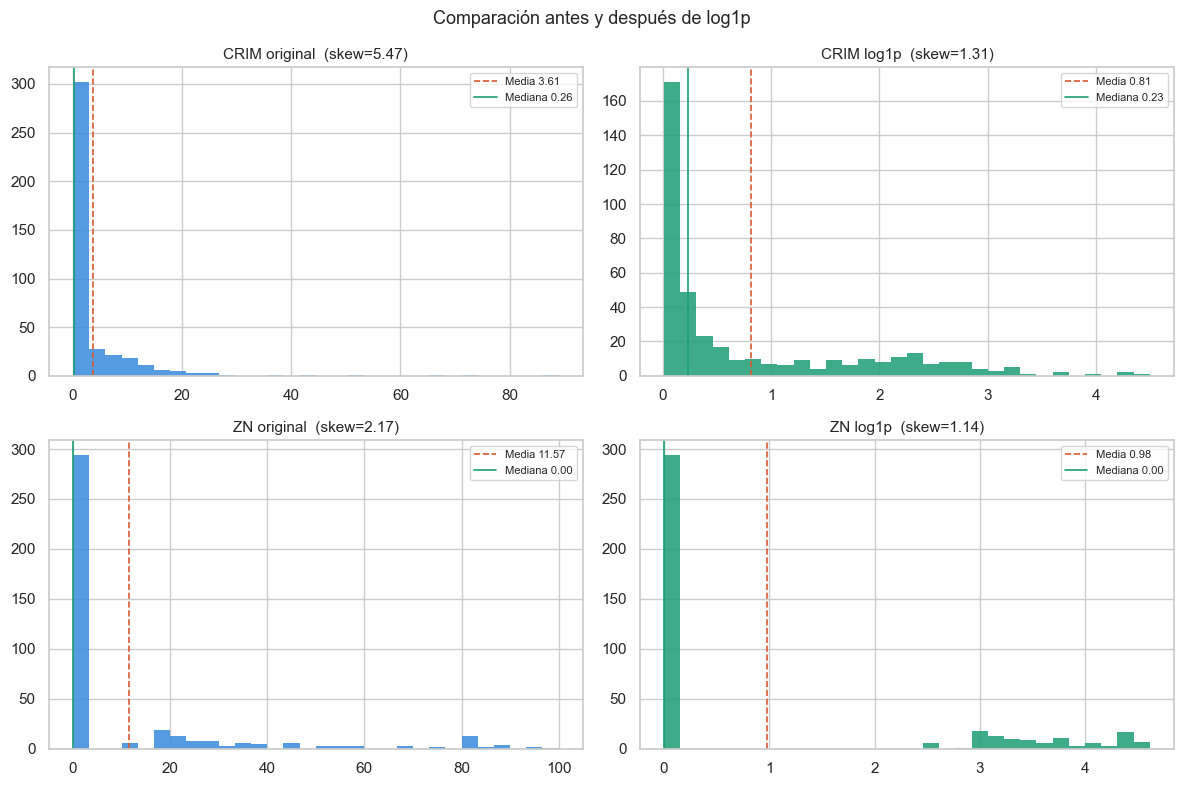

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for i, feat in enumerate(features_to_transform):
    # antes: recuperamos los valores originales con exp
    original    = np.expm1(X_train[feat])
    transformada = X_train[feat]

    ax_antes   = axes[i, 0]
    ax_despues = axes[i, 1]

    skew_antes   = original.skew()
    skew_despues = transformada.skew()

    ax_antes.hist(original, bins=30, color="#378ADD", edgecolor="none", alpha=0.85)
    ax_antes.axvline(original.mean(),   color="#D85A30", linewidth=1.2, linestyle="--", label=f"Media {original.mean():.2f}")
    ax_antes.axvline(original.median(), color="#1D9E75", linewidth=1.2, linestyle="-",  label=f"Mediana {original.median():.2f}")
    ax_antes.set_title(f"{feat} original  (skew={skew_antes:.2f})", fontsize=11)
    ax_antes.legend(fontsize=8)

    ax_despues.hist(transformada, bins=30, color="#1D9E75", edgecolor="none", alpha=0.85)
    ax_despues.axvline(transformada.mean(),   color="#D85A30", linewidth=1.2, linestyle="--", label=f"Media {transformada.mean():.2f}")
    ax_despues.axvline(transformada.median(), color="#1D9E75", linewidth=1.2, linestyle="-",  label=f"Mediana {transformada.median():.2f}")
    ax_despues.set_title(f"{feat} log1p  (skew={skew_despues:.2f})", fontsize=11)
    ax_despues.legend(fontsize=8)

fig.suptitle("Comparación antes y después de log1p", fontsize=13)
plt.tight_layout()
plt.show()

**Escalado**

In [27]:
escalar = StandardScaler()

X_train = pd.DataFrame(escalar.fit_transform(X_train), columns=features, index=X_train.index)
X_test = pd.DataFrame(escalar.transform(X_test), columns=features, index= X_test.index)

print("\n" + "=" * 60)
print("ESCALADO StandardScaler")
print("=" * 60)
print("\nMedia tras escalado (debe ser ~0):")
print(X_train.mean().round(3).to_string())
print("\nStd tras escalado (debe ser ~1):")
print(X_train.std().round(3).to_string())


ESCALADO StandardScaler

Media tras escalado (debe ser ~0):
LSTAT     -0.0
RM        -0.0
PTRATIO    0.0
INDUS     -0.0
CRIM      -0.0
DIS        0.0
ZN        -0.0
TAX       -0.0

Std tras escalado (debe ser ~1):
LSTAT      1.001
RM         1.001
PTRATIO    1.001
INDUS      1.001
CRIM       1.001
DIS        1.001
ZN         1.001
TAX        1.001


7. Construye un modelo de regresión lineal.

In [28]:
# Modelo de regresión lineal
model = LinearRegression()
model.fit(X_train, y_train)

# Predicciones
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

metrics = pd.DataFrame({
    "Train": [
        mean_absolute_error(y_train, y_train_pred),
        np.sqrt(mean_squared_error(y_train, y_train_pred)),
        r2_score(y_train, y_train_pred)
    ],
    "Test": [
        mean_absolute_error(y_test, y_test_pred),
        np.sqrt(mean_squared_error(y_test, y_test_pred)),
        r2_score(y_test, y_test_pred)
    ]

}, index=["MAE", "RMSE", "R2"])

print(metrics)

         Train      Test
MAE   3.537526  3.269290
RMSE  5.012654  5.133861
R2    0.710766  0.640595


8. Analiza si lo crees conveniente los pesos y la importancia de las features.


COEFICIENTES DEL MODELO

  Intercept: 22.7965

     LSTAT  -4.2986
        RM  +3.2289
       DIS  -2.3246
   PTRATIO  -1.4918
        ZN  +0.6733
       TAX  -0.6166
      CRIM  -0.5633
     INDUS  -0.4204


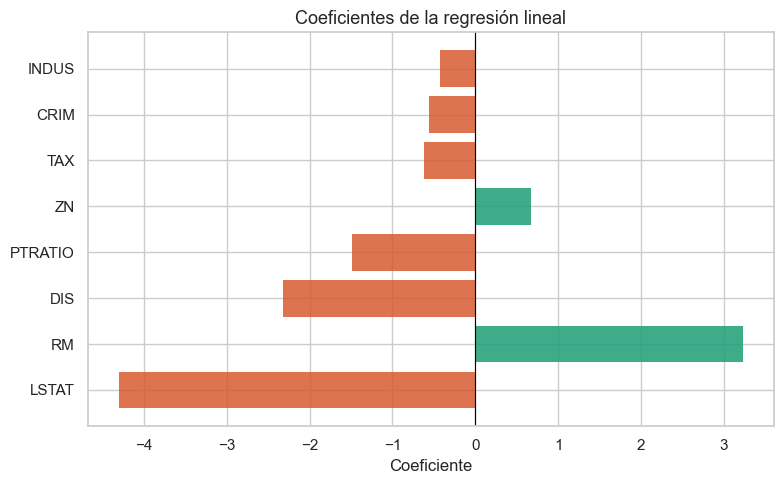

In [29]:
# ─────────────────────────────────────────────
# PESOS E IMPORTANCIA DE LAS FEATURES
# ─────────────────────────────────────────────
coef_df = pd.DataFrame({
    "feature": features,
    "coeficiente": model.coef_.flatten()
}).sort_values("coeficiente", key=abs, ascending=False).reset_index(drop=True)

print("\n" + "=" * 60)
print("COEFICIENTES DEL MODELO")
print("=" * 60)
print(f"\n  Intercept: {model.intercept_[0]:.4f}\n")
for _, row in coef_df.iterrows():
    direccion = "+" if row["coeficiente"] > 0 else "-"
    print(f"  {row['feature']:>8}  {row['coeficiente']:+.4f}")

# Gráfico
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#1D9E75" if v > 0 else "#D85A30" for v in coef_df["coeficiente"]]
ax.barh(coef_df["feature"], coef_df["coeficiente"], color=colors, edgecolor="none", alpha=0.85)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Coeficientes de la regresión lineal", fontsize=13)
ax.set_xlabel("Coeficiente")
plt.tight_layout()
plt.show()

**Variables que suben el precio (positivas)**
* **RM (+3.23)**: cada desviación típica extra en el número de habitaciones sube el precio 3230$. Lógico más habitaciones = vivienda más cara.
* **ZN (+0.67)**: más suelo residencial en la zona sube ligeramente el precio.

**Variables que bajan el precio (negativas)**
* **LSTAT (-4.30)**: es la feature más influyente. A mayor porcentaje de población de clase baja, menor precio. Coherente con la correlación de 0.74 que vimos en el EDA.
* **DIS (-2.32)**: las zonas más alejadas de los centros de empleo tienden a ser más baratas.
* **PTRATIO (-1.49)**: más alumnos por profesor implica peor calidad educativa y menor precio.
* **TAX (0.62)**: mayor tasa impositiva, menor precio.
* **CRIM (-0.56)**: más criminalidad menos precio.
* **INDUS (-0.42)**: más suelo industrial, menos precio.


9. Evalúa tu modelo. Haz un pequeño assesmente de su generabilidad. Compara gráficamente las predicciones con los valores reales.


MÉTRICAS TRAIN VS TEST
         Train      Test
MAE   3.537526  3.269290
RMSE  5.012654  5.133861
R2    0.710766  0.640595


C:\Users\user\AppData\Local\Temp\ipykernel_18800\3067809613.py:19: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  min_val = min(float(y_real.min()), float(y_pred.min()))
C:\Users\user\AppData\Local\Temp\ipykernel_18800\3067809613.py:20: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  max_val = max(float(y_real.max()), float(y_pred.max()))
C:\Users\user\AppData\Local\Temp\ipykernel_18800\3067809613.py:19: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  min_val = min(float(y_real.min()), float(y_pred.min()))
C:\Users\user\AppData\Local\Temp\ipykernel_18800\3067809613.py:20: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.ilo

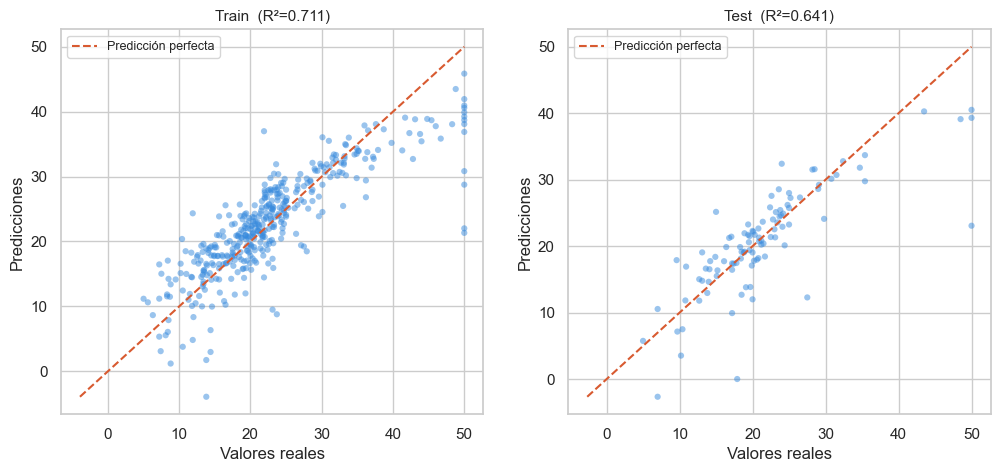

In [30]:
# ─────────────────────────────────────────────
# EVALUACIÓN DEL MODELO
# ─────────────────────────────────────────────

# 1. Métricas train vs test
print("\n" + "=" * 60)
print("MÉTRICAS TRAIN VS TEST")
print("=" * 60)
print(metrics)

# 2. Gráfico predicciones vs valores reales
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, nombre, y_real, y_pred in [
    (axes[0], "Train", y_train, y_train_pred),
    (axes[1], "Test",  y_test,  y_test_pred)
]:
    ax.scatter(y_real, y_pred, alpha=0.5, s=20, color="#378ADD", edgecolors="none")
    min_val = min(float(y_real.min()), float(y_pred.min()))
    max_val = max(float(y_real.max()), float(y_pred.max()))
    ax.plot([min_val, max_val], [min_val, max_val], color="#D85A30", linewidth=1.5, linestyle="--", label="Predicción perfecta")
    ax.set_title(f"{nombre}  (R²={r2_score(y_real, y_pred):.3f})", fontsize=11)
    ax.set_xlabel("Valores reales")
    ax.set_ylabel("Predicciones")
    ax.legend(fontsize=9)



**El modelo captura bien la tendencia general**: los puntos siguen la diagonal en la zona central (15-35), que es donde se concentran la mayoría de las observaciones.

**Sesgo en lo extremos**:
* Zona baja (0-10): el modelo sobreestima, los puntos quedan por encima de la diagonal.
* Zona alta (40-50): el modelo subestima, los puntos quedan por debajo.

    Especialmente el grupo concentrado en 50 que predice entre 20 y 40.

<Figure size 640x480 with 0 Axes>

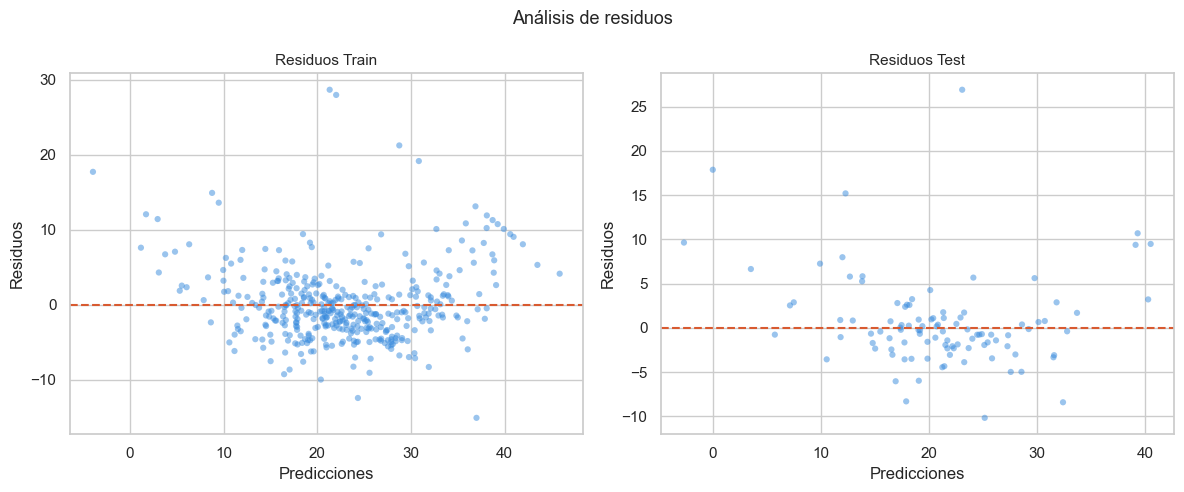

In [31]:
fig.suptitle("Predicciones vs valores reales", fontsize=13)
plt.tight_layout()
plt.show()

# 3. Gráfico de residuos
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, nombre, y_real, y_pred in [
    (axes[0], "Train", y_train, y_train_pred),
    (axes[1], "Test",  y_test,  y_test_pred)
]:
    residuos = y_real - y_pred
    ax.scatter(y_pred, residuos, alpha=0.5, s=20, color="#378ADD", edgecolors="none")
    ax.axhline(0, color="#D85A30", linewidth=1.5, linestyle="--")
    ax.set_title(f"Residuos {nombre}", fontsize=11)
    ax.set_xlabel("Predicciones")
    ax.set_ylabel("Residuos")

fig.suptitle("Análisis de residuos", fontsize=13)
plt.tight_layout()
plt.show()

**Los residuos (diferencia entre el valor real y la predicción)  muestran varios problemas**
* **Heterocedasticidad**: la varianza de los residuos no es constante.
    
    En predicciones bajas (0-10) hay residuos muy grandes positivos, mientras que en predicciones medias (20-30) los residuos son más pequeños y negativos.
    
    Esto explica el sesgo que ya veíamos en el gráfico anterior.

* **Patrón no aleatorio**: los residuos no se distribuyen aleatoriamente alrededor del 0 sino que forman una estructura, lo que confirma que la relacion entre las features

    y la target tiene componentes que la regresión lineal no puede capturar.

* **Outliers en residuos**: hay varios puntos con residuos superiores a 20, tanto en train como en test, que el modelo no es capaz de calcular.

**Assessment de generalización:**
* La caida de $R^2$ de 0.71 a 0.64 entre train y test es moderada, no hay overfitting severo.
* Sin embargo el RMSE sube ligeramente del 5.01 al 5.13, confirmando que el modelo generaliza con un error algo mayor en datos nuevos.
* El MAE mejora en test (3.27 vs 3.54), lo que indica que los outliers están más concetrados en train

### **Conclusión**

El modelo es estable y generaliza razonablemente ($R^2$=0.64 en test), pero sus limitaciones son estructurales. Un modelo no lineal capturaría mejor los extremos y reduciría la heterocedasticidad

10. Regulariza al menos con un modelo alternativo y juega con 3 posibles valores de los hiperparámetros del modelo de regularización.

In [ ]:
# ─────────────────────────────────────────────
# RIDGE CON 3 VALORES DE ALPHA
# ─────────────────────────────────────────────
alphas = [0.01, 0.1, 1.0]

resultados = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train, y_train)

    y_train_pred = ridge.predict(X_train)
    y_test_pred  = ridge.predict(X_test)

    resultados.append({
        "alpha":      alpha,
        "R2_train":   r2_score(y_train, y_train_pred),
        "R2_test":    r2_score(y_test,  y_test_pred),
        "RMSE_train": np.sqrt(mean_squared_error(y_train, y_train_pred)),
        "RMSE_test":  np.sqrt(mean_squared_error(y_test,  y_test_pred)),
        "MAE_train":  mean_absolute_error(y_train, y_train_pred),
        "MAE_test":   mean_absolute_error(y_test,  y_test_pred),
    })

print("\n" + "=" * 60)
print("RIDGE — COMPARATIVA DE ALPHAS")
print("=" * 60)
resultados_df = pd.DataFrame(resultados)
print(resultados_df.round(4).to_string(index=False))



RIDGE — COMPARATIVA DE ALPHAS
 alpha  R2_train  R2_test  RMSE_train  RMSE_test  MAE_train  MAE_test
  0.01    0.7108   0.6406      5.0127     5.1338     3.5375    3.2692
  0.10    0.7108   0.6406      5.0127     5.1337     3.5374    3.2689
  1.00    0.7108   0.6408      5.0127     5.1322     3.5359    3.2652



LASSO — COMPARATIVA DE ALPHAS
 alpha  R2_train  R2_test  RMSE_train  RMSE_test  MAE_train  MAE_test  features_activas
  0.01    0.7108   0.6407      5.0128     5.1331     3.5346    3.2634                 8
  0.10    0.7093   0.6401      5.0253     5.1373     3.5214    3.2469                 8
  1.00    0.6679   0.6274      5.3717     5.2273     3.7594    3.4608                 3


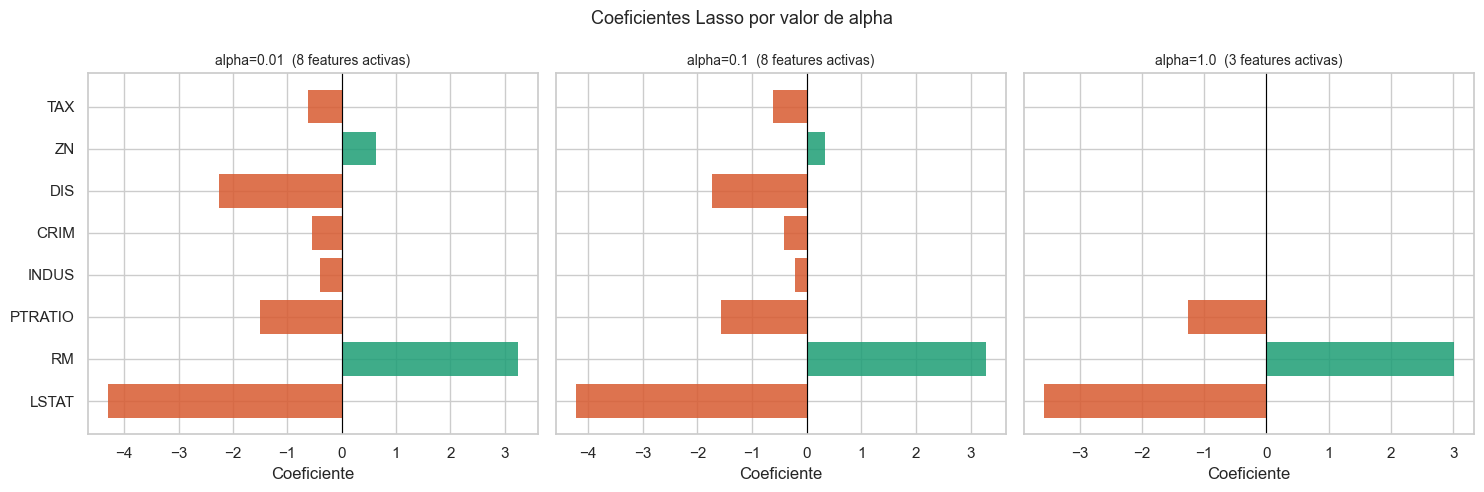

In [ ]:
# ─────────────────────────────────────────────
# LASSO CON 3 VALORES DE ALPHA
# ─────────────────────────────────────────────
alphas = [0.01, 0.1, 1.0]

resultados = []

for alpha in alphas:
    lasso = Lasso(alpha=alpha, random_state=42)
    lasso.fit(X_train, y_train)

    y_train_pred = lasso.predict(X_train)
    y_test_pred  = lasso.predict(X_test)

    features_activas = sum(lasso.coef_ != 0)

    resultados.append({
        "alpha":            alpha,
        "R2_train":         r2_score(y_train, y_train_pred),
        "R2_test":          r2_score(y_test,  y_test_pred),
        "RMSE_train":       np.sqrt(mean_squared_error(y_train, y_train_pred)),
        "RMSE_test":        np.sqrt(mean_squared_error(y_test,  y_test_pred)),
        "MAE_train":        mean_absolute_error(y_train, y_train_pred),
        "MAE_test":         mean_absolute_error(y_test,  y_test_pred),
        "features_activas": features_activas,
        "coeficientes":     lasso.coef_
    })

# Tabla de métricas
print("\n" + "=" * 60)
print("LASSO — COMPARATIVA DE ALPHAS")
print("=" * 60)
resultados_df = pd.DataFrame(resultados).drop(columns="coeficientes")
print(resultados_df.round(4).to_string(index=False))

# Gráfico de coeficientes por alpha
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, res in zip(axes, resultados):
    coef = res["coeficientes"]
    colors = ["#1D9E75" if v > 0 else "#D85A30" if v < 0 else "#B4B2A9" for v in coef]
    ax.barh(features, coef, color=colors, edgecolor="none", alpha=0.85)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"alpha={res['alpha']}  ({res['features_activas']} features activas)", fontsize=10)
    ax.set_xlabel("Coeficiente")

fig.suptitle("Coeficientes Lasso por valor de alpha", fontsize=13)
plt.tight_layout()
plt.show()

11. Expresa tus conclusiones, en concreto ¿con qué modelo te quedarías?¿por qué?

## Conclusiones del análisis

A lo largo del ejercicio hemos construido y evaluado tres modelos: regresión lineal, Lasso y Ridge.

### Resultados en test

| Modelo | R² test | RMSE test | MAE test |
|---|---|---|---|
| Regresión lineal | 0.6406 | 5.1339 | 3.2693 |
| Lasso (α=0.1) | 0.6401 | 5.1373 | 3.2469 |
| Ridge (α=1.0) | 0.6408 | 5.1322 | 3.2652 |

### Modelo elegido: Ridge (α=1.0)

**Mejor métrica en test**: aunque la diferencia es mínima, Ridge con α=1.0 obtiene
el mejor R² (0.6408) y el mejor RMSE (5.1322) en test de los tres modelos.

**Más estable ante multicolinealidad**: vimos en el EDA que algunas features tenían
correlación moderada entre sí. Ridge penaliza los coeficientes grandes sin eliminar
features, distribuyendo mejor el peso entre variables correlacionadas.

**Todas las features son relevantes**: Lasso con α=1.0 demostró que eliminar features
empeora el modelo, lo que justifica usar Ridge que las conserva todas.

### Limitaciones

El modelo presenta heterocedasticidad y sesgo sistemático en los extremos del rango
de precios, con un R² de 0.64 en test que deja un 36% de la varianza sin explicar.
Estas limitaciones son estructurales y no se resuelven con regularización, ya que
la relación entre las features y MEDV tiene componentes no lineales que ningún modelo
lineal puede capturar.

### Siguiente paso

Un modelo no lineal como Random Forest o Gradient Boosting capturaría mejor las
relaciones no lineales entre las features y el precio, reduciría el sesgo en los
extremos y probablemente mejoraría el R² en test por encima de 0.80.

In [41]:
from sklearn.ensemble import RandomForestRegressor

# ─────────────────────────────────────────────
# RANDOM FOREST
# ─────────────────────────────────────────────
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_train_pred_rf = rf.predict(X_train)
y_test_pred_rf  = rf.predict(X_test)

print("\n" + "=" * 60)
print("RANDOM FOREST — MÉTRICAS")
print("=" * 60)

metrics_rf = pd.DataFrame({
    "Train": [
        r2_score(y_train, y_train_pred_rf),
        np.sqrt(mean_squared_error(y_train, y_train_pred_rf)),
        mean_absolute_error(y_train, y_train_pred_rf)
    ],
    "Test": [
        r2_score(y_test, y_test_pred_rf),
        np.sqrt(mean_squared_error(y_test, y_test_pred_rf)),
        mean_absolute_error(y_test, y_test_pred_rf)
    ]
}, index=["R2", "RMSE", "MAE"])

print(metrics_rf.round(4))

c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)



RANDOM FOREST — MÉTRICAS
       Train    Test
R2    0.9767  0.8630
RMSE  1.4220  3.1700
MAE   0.9264  2.2014


## Random Forest

### Resultados

| Métrica | Train | Test |
|---|---|---|
| R² | 0.9767 | 0.8630 |
| RMSE | 1.4220 | 3.1700 |
| MAE | 0.9264 | 2.2014 |

### Análisis

**Mejora clara sobre los modelos lineales**: el R² en test sube de 0.64 a 0.86,
el RMSE baja de 5.13 a 3.17 y el MAE de 3.27 a 2.20. Random Forest captura mejor
las relaciones no lineales entre las features y MEDV que el modelo lineal probado.

**Overfitting evidente**: la diferencia entre train y test es grande en todas las
métricas. El modelo memoriza casi perfectamente el train (R²=0.98, RMSE=1.42) pero
generaliza peor en datos nuevos (R²=0.86, RMSE=3.17).

### Conclusión

A pesar del overfitting, Random Forest supera ampliamente al modelo lineal en
test. Para reducir el sobreajuste convendría actuar sobre los hiperparámetros.